# Notebook Exploration des Données

l'analyse se concentre sur la zone 10N-123W-45N, car c'est la seule zone que j'ai téléchargée localement de la base de données (trop volumineux autrement).

### Prise en main des fichiers tiffs 

"" The dataset contains daily Planet Fusion imagery with monthly land cover classes for 75 areas across the globe over two years. The seven land cover classes were manually annotated in a temporally consistent way.  ""

In [43]:
import sys
import os
from pathlib import Path

import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
# gdal
#pyproj 
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath("src"))

from sat_image_reader import SatImageReader
from classes_reader import ClassesReader


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
path_dataset = "../../../../tsi/data_education/fil_rouge_Airbus_2025/dynamic_earth_net/"
path_testdata = "planet.10N/planet/10N/19E-211N/1286_2921_13/PF-SR/"
path_label = "labels/labels/1311_3077_13_10N/Labels/Raster/10N-122W-40N-L3H-SR/10N-122W-40N-L3H-SR-2018_01_01.tif"

path = path_dataset + path_label

In [5]:
with rasterio.open(path) as dataset:
    
    print("Métadonnées:", dataset.meta)


Métadonnées: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1024, 'height': 1024, 'count': 7, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 551971.4999999972,
       0.0, -3.0, 4517971.500000001)}


Nombre de bandes: 7


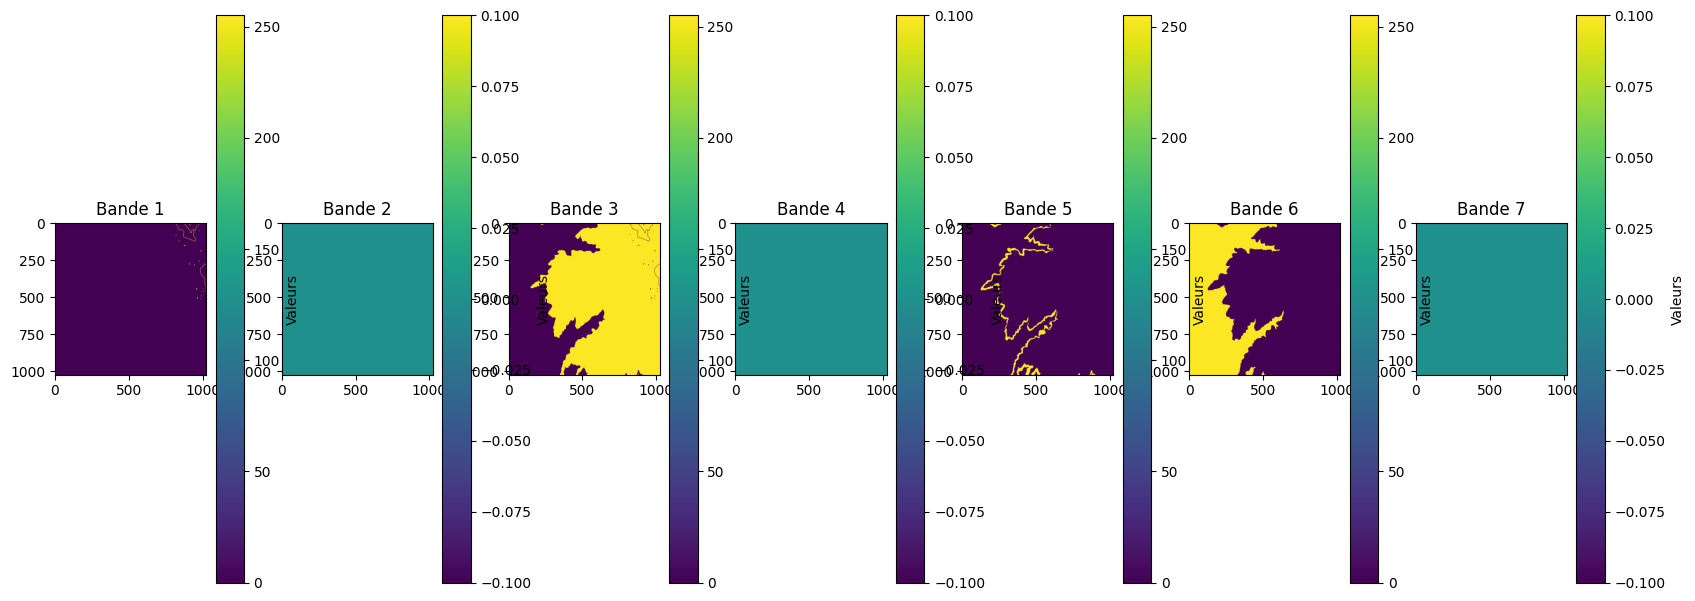

In [6]:

with rasterio.open(path) as dataset:
    n_band = dataset.count
    print("Nombre de bandes:", n_band)
    plt.subplots(1, n_band, figsize=(20, 10))
    for i in range(1, n_band+1):
        band = dataset.read(i)
        plt.subplot(1, n_band, i)
        plt.imshow(band)
        plt.colorbar(label='Valeurs')
        plt.title(f'Bande {i}')
        
    plt.show()
    

On remarque que sur cette zone seulement 3 classes de 7 sont présentes. Les noms des classes sont visibles dans le folder 'vector'.

 - [ ] La bande 1 correspond à "Impervious Surface". 
 - [ ] La bande 3 correspond à "Forest and other Vegetation".
 - [ ] La bande 5 correspond à "Soil". 

#### visualisation des évolutions temporelles 

Métadonnées: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1024, 'height': 1024, 'count': 7, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 551971.4999999972,
       0.0, -3.0, 4517971.500000001)}


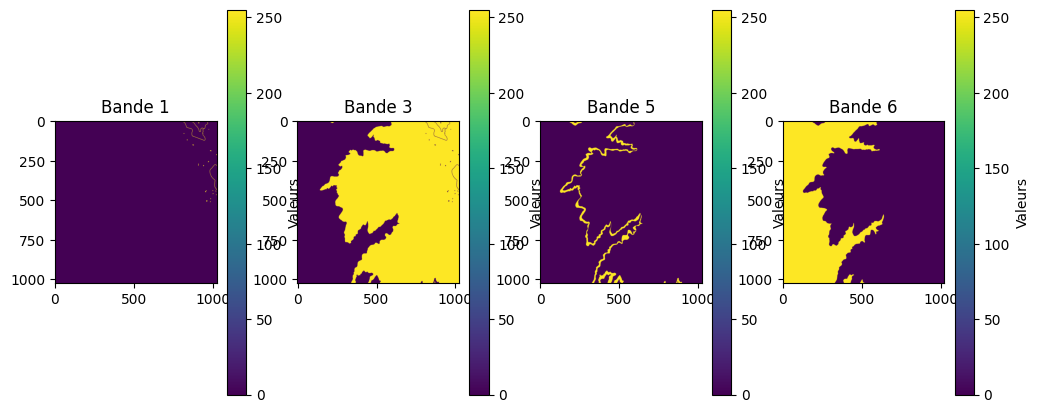

Métadonnées: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1024, 'height': 1024, 'count': 7, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 551971.4999999972,
       0.0, -3.0, 4517971.500000001)}


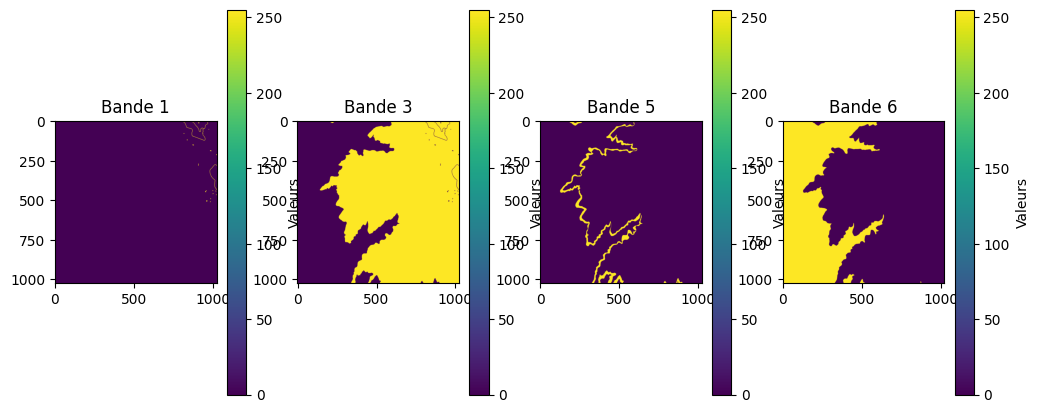

Métadonnées: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1024, 'height': 1024, 'count': 7, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 551971.4999999972,
       0.0, -3.0, 4517971.500000001)}


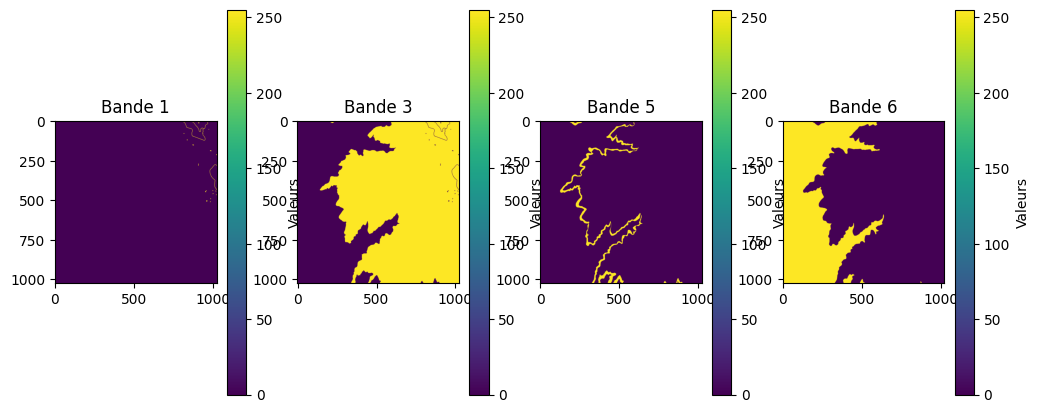

Métadonnées: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1024, 'height': 1024, 'count': 7, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 551971.4999999972,
       0.0, -3.0, 4517971.500000001)}


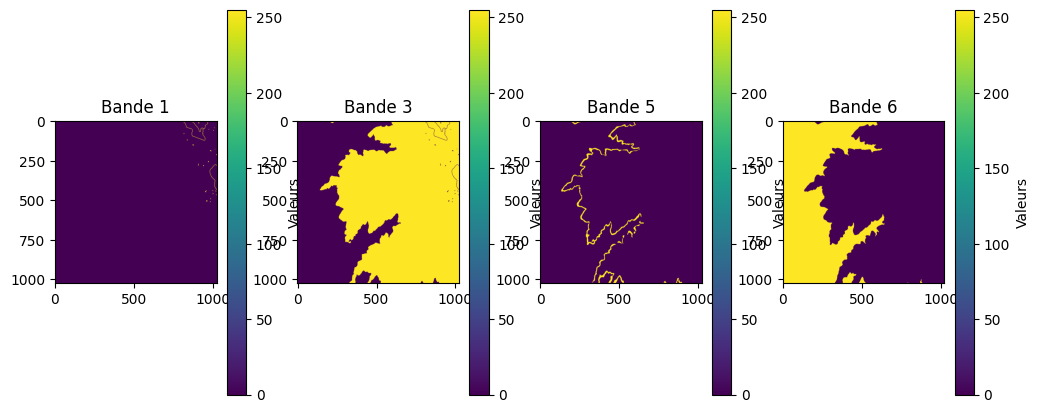

Métadonnées: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1024, 'height': 1024, 'count': 7, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 551971.4999999972,
       0.0, -3.0, 4517971.500000001)}


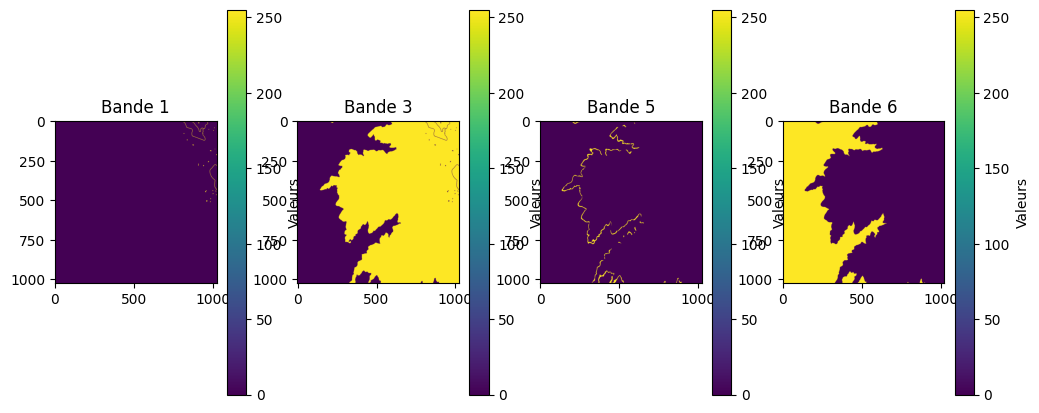

Métadonnées: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1024, 'height': 1024, 'count': 7, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 551971.4999999972,
       0.0, -3.0, 4517971.500000001)}


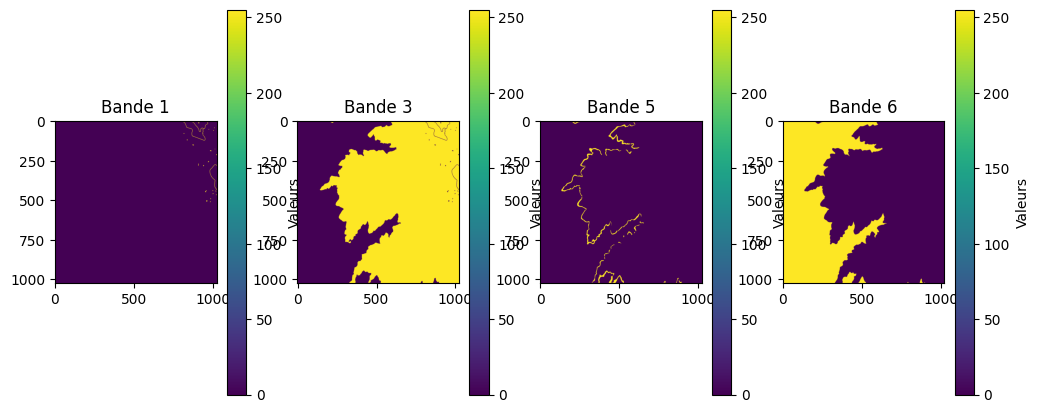

Métadonnées: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1024, 'height': 1024, 'count': 7, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 551971.4999999972,
       0.0, -3.0, 4517971.500000001)}


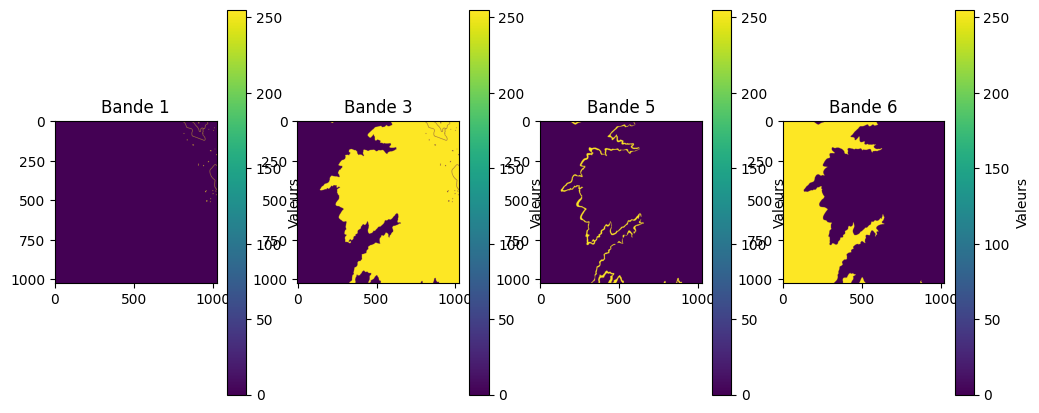

Métadonnées: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1024, 'height': 1024, 'count': 7, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 551971.4999999972,
       0.0, -3.0, 4517971.500000001)}


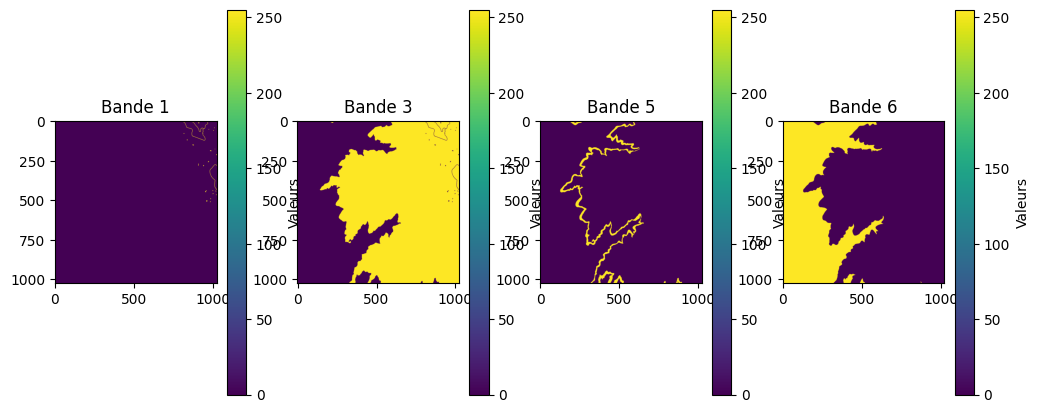

Métadonnées: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1024, 'height': 1024, 'count': 7, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 551971.4999999972,
       0.0, -3.0, 4517971.500000001)}


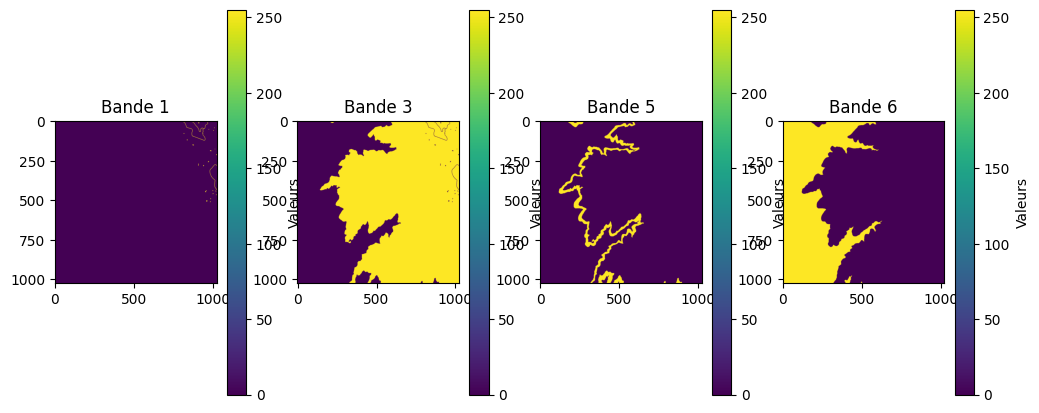

Métadonnées: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1024, 'height': 1024, 'count': 7, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 551971.4999999972,
       0.0, -3.0, 4517971.500000001)}


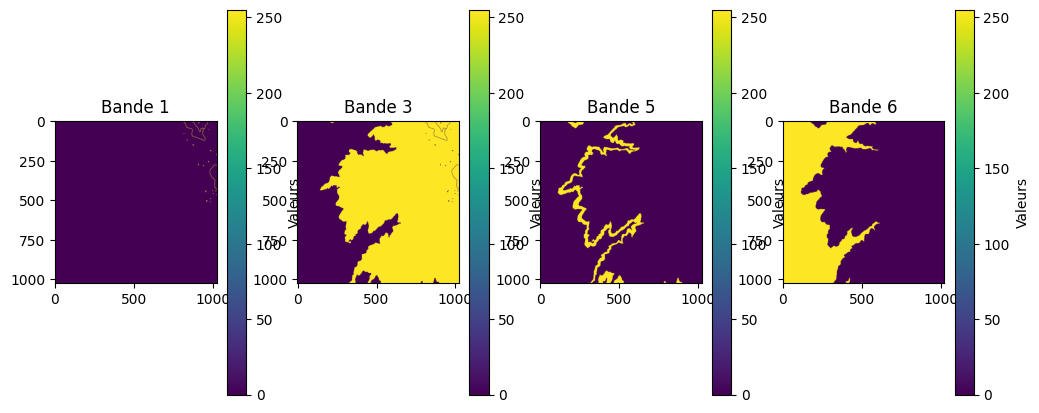

Métadonnées: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1024, 'height': 1024, 'count': 7, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 551971.4999999972,
       0.0, -3.0, 4517971.500000001)}


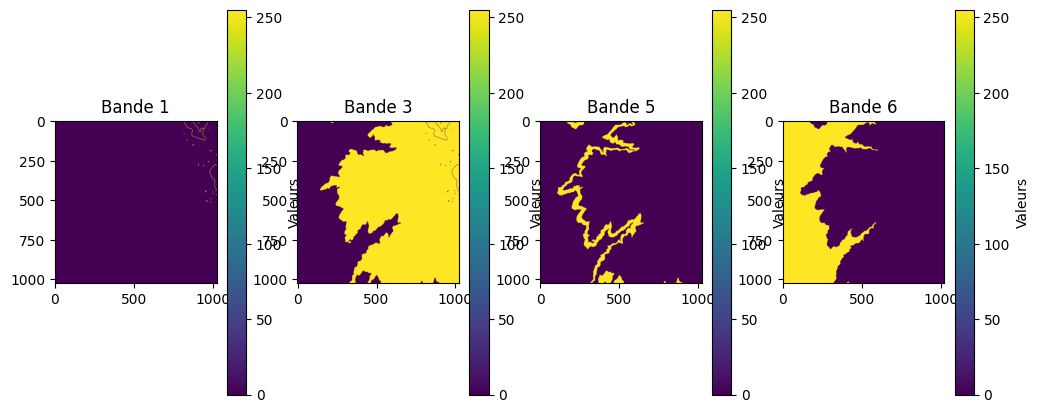

Métadonnées: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1024, 'height': 1024, 'count': 7, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 551971.4999999972,
       0.0, -3.0, 4517971.500000001)}


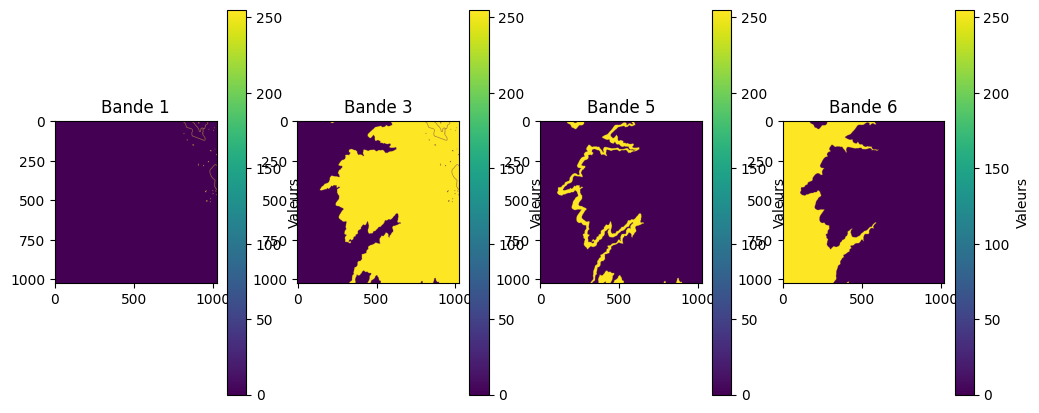

In [7]:
path = path_dataset + path_testdata
path_folder = path_dataset + "labels/labels/1311_3077_13_10N/Labels/Raster/10N-122W-40N-L3H-SR/"
for i in range(1, 13):
    num = str(i).zfill(2)
    path = path_folder + f"10N-122W-40N-L3H-SR-2018_{num}_01.tif"
    with rasterio.open(path) as dataset:
        print("Métadonnées:", dataset.meta)
        plt.subplots(1, 4, figsize=(12, 5))
        for i in range(1, n_band+1):
            if i in [1, 3, 5, 6]:
                band = dataset.read(i)
                plt.subplot(1, 4, [1,3,5,6].index(i)+1)
                plt.imshow(band)
                plt.colorbar(label='Valeurs')
                plt.title(f'Bande {i}')
            
        plt.show()

Band 1 - min: 0 max: 255
Band 3 - min: 0 max: 255
Band 5 - min: 0 max: 255


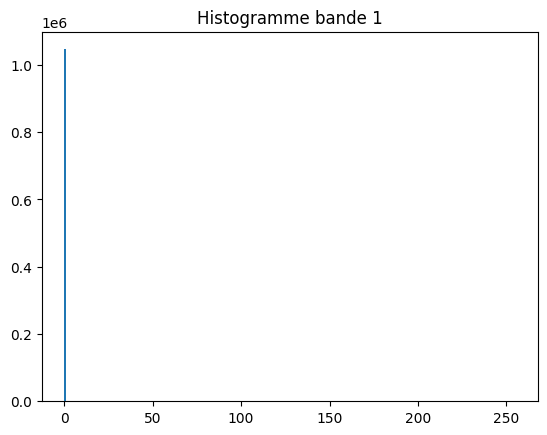

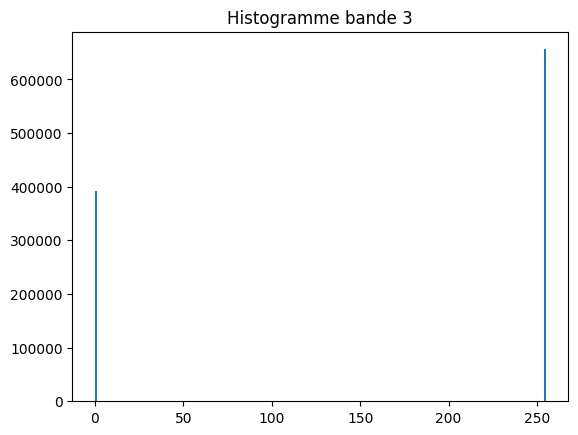

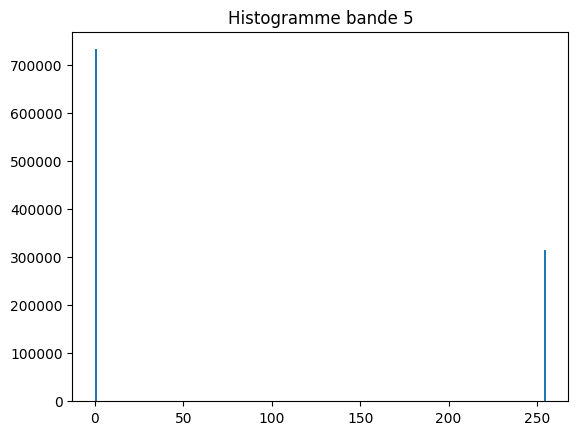

In [8]:

# Ouvrir le fichier raster
dataset = rasterio.open(path)

# Lire les bandes 1, 3 et 5
band1 = dataset.read(1)
band3 = dataset.read(3)
band5 = dataset.read(5)
band5 = dataset.read(6)

print('Band 1 - min:', band1.min(), 'max:', band1.max())
print('Band 3 - min:', band3.min(), 'max:', band3.max())
print('Band 5 - min:', band5.min(), 'max:', band5.max())


plt.hist(band1.flatten(), bins=256, range=(band1.min(), band1.max()))
plt.title('Histogramme bande 1')
plt.show()

plt.hist(band3.flatten(), bins=256, range=(band3.min(), band3.max()))
plt.title('Histogramme bande 3')
plt.show()

plt.hist(band5.flatten(), bins=256, range=(band5.min(), band5.max()))
plt.title('Histogramme bande 5')
plt.show()


#### Visualisation des Histogramme :

On voit que chaque images à des valeurs soit 0, soit 255. ce qui correspond à apartenir à la classe ou non. On remarque que certaines parties des images appartiennent à plusieurs classes à la fois.


### Prise en main des geojson

In [9]:
path_geojson_forest = "../data/test_data/1286_2921_13_10N/Labels/Vector/Forest_and_Other_Vegetation/10N-123W-45N-L3H-SR/10N-123W-45N-L3H-SR-2018_01_01.geojson"
path_geojson_soil = "../data/test_data/1286_2921_13_10N/Labels/Vector/Soil/10N-123W-45N-L3H-SR/10N-123W-45N-L3H-SR-2018_01_01.geojson"
path_geojson_imp_surface = "../data/test_data/1286_2921_13_10N/Labels/Vector/Impervious_Surface/10N-123W-45N-L3H-SR/10N-123W-45N-L3H-SR-2018_01_01.geojson"


In [10]:
gdf_forest = gpd.read_file(path_geojson_forest)

print(gdf_forest.head())

gdf_forest.plot()
plt.title("geojson Forest_and_Other_Vegetation")
plt.show()


gdf_soil = gpd.read_file(path_geojson_soil)

print(gdf_soil.head())

gdf_soil.plot()
plt.title("geojson Soil")
plt.show()


gdf_imp_surface = gpd.read_file(path_geojson_imp_surface)

print(gdf_imp_surface.head())

gdf_imp_surface.plot()
plt.title("geojson Imperivous_Surface")
plt.show()


DataSourceError: ../data/test_data/1286_2921_13_10N/Labels/Vector/Forest_and_Other_Vegetation/10N-123W-45N-L3H-SR/10N-123W-45N-L3H-SR-2018_01_01.geojson: No such file or directory

# Visualisation des images satellites 

### Analyse des image dans PF-SR

#### Image RGB

In [44]:
path_img = "planet.10N/planet/10N/23E-188N/1311_3077_13/PF-SR/2018-01-01.tif"

Profile du dataset: {'driver': 'GTiff', 'dtype': 'int16', 'nodata': None, 'width': 1024, 'height': 1024, 'count': 4, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 551971.4999999972,
       0.0, -3.0, 4517971.500000001), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'lzw', 'interleave': 'pixel'}
Métadonnées: {'driver': 'GTiff', 'dtype': 'int16', 'nodata': None, 'width': 1

Exception ignored in: <function ClassesReader.__del__ at 0x7f85a3787760>
Traceback (most recent call last):
  File "/home/ids/henry-24/Computer_Vision_Projet/src/classes_reader.py", line 32, in __del__
    if self.image and not self.image.closed:
AttributeError: 'ClassesReader' object has no attribute 'image'


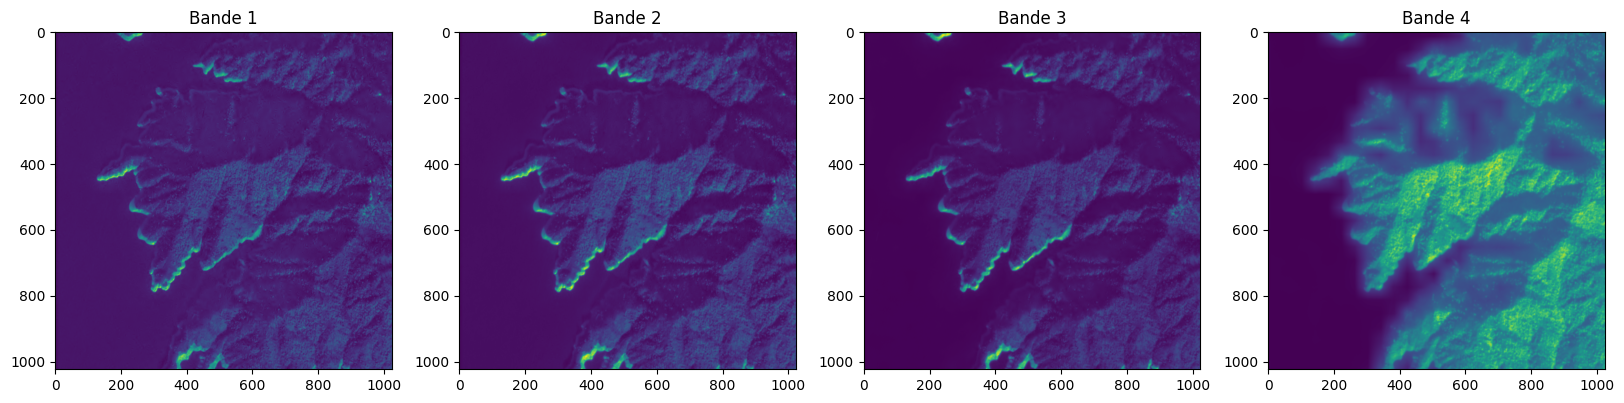

In [45]:
with rasterio.open(path_dataset+path_img) as dataset:
    n_band = dataset.count
    print("Profile du dataset:", dataset.profile)
    print("Métadonnées:", dataset.meta)
    print("Nombre de bandes:", n_band)
    plt.subplots(1, n_band, figsize=(20, 10))
    for i in range(1, n_band+1):
        band = dataset.read(i)
        plt.subplot(1, n_band, i)
        plt.imshow(band)
        plt.title(f'Bande {i}')
        
    plt.show()

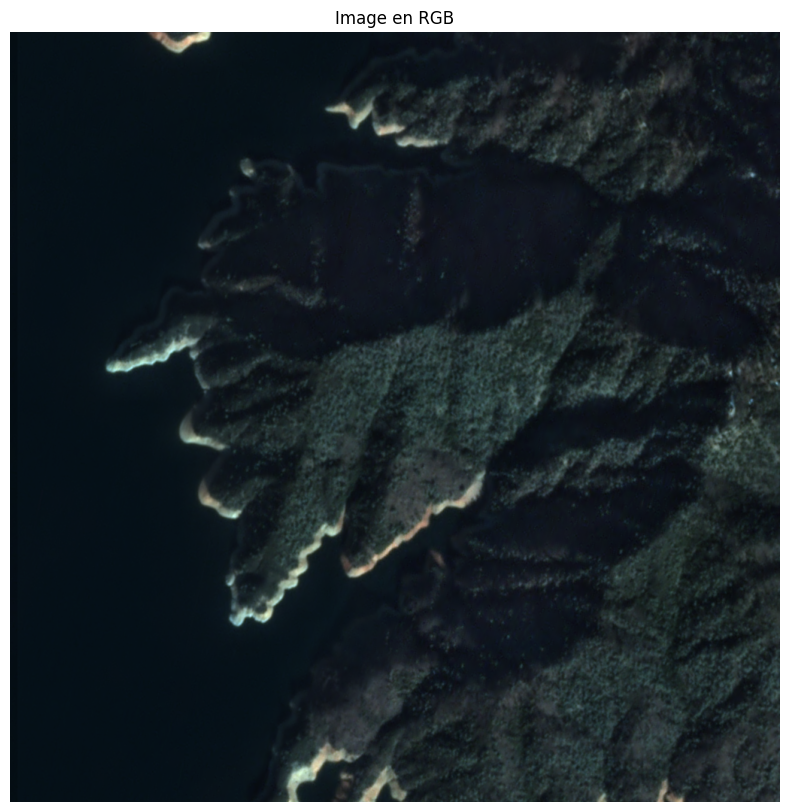

In [46]:

with rasterio.open(path_dataset+path_img) as src:
    
    red = src.read(3) 
    green = src.read(2) 
    blue = src.read(1)  

    red = red / red.max()
    green = green / green.max()
    blue = blue / blue.max()

    rgb_image = np.dstack((red, green, blue))

# image rgb normalisée
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image)
plt.title("Image en RGB")
plt.axis("off")
plt.show()


In [27]:

project_root = Path.cwd().parent 
src_path = project_root / "src"
sys.path.append(str(src_path))


In [47]:
img = SatImageReader(path_dataset+path_img)

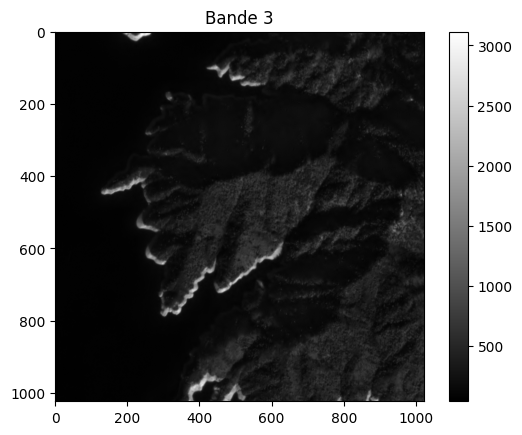

In [31]:
img.show_band(3)

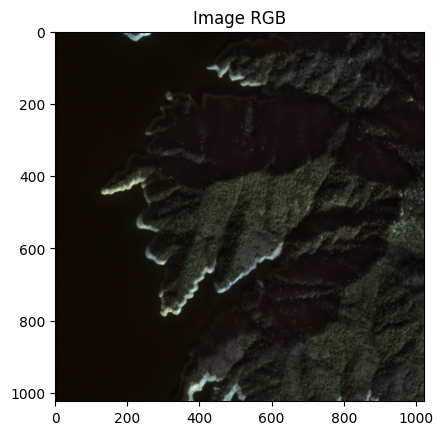

In [49]:
img.show_rgb()

#### Histogramme 

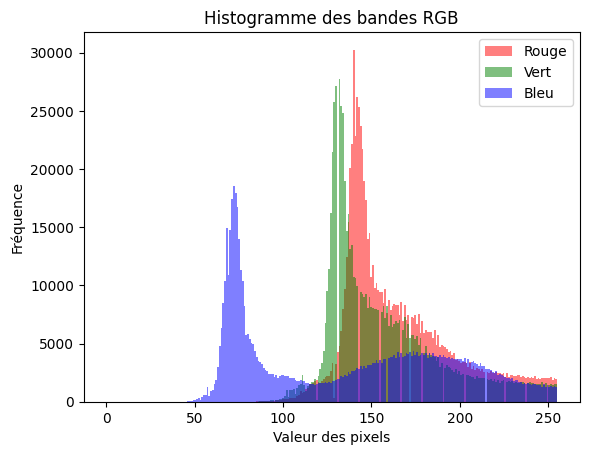

In [51]:
img.show_rgb_hist(bands_rgb = (1,2,3),show_infrared=False)

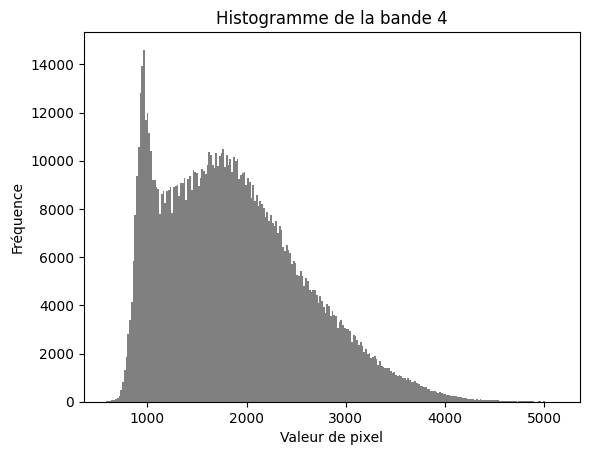

In [17]:
img.show_band_hist(4)

#### Calcul de l'indice de végétation par différence (NDVI)

Indice allant de -1 à 1 ?
* \< 0 : Eau, surfaces enneigées ou nuages.
* ~0 : Sols nus ou surfaces minérales.
* 0,2 à 0,5 : Végétation clairsemée ou stressée.
* \> 0,5 : Végétation dense et en bonne santé.

In [34]:
img.calculate_ndvi()

array([[0.12903225, 0.11111111, 0.10236221, ..., 0.72595155, 0.7616959 ,
        0.7383592 ],
       [0.1570248 , 0.12903225, 0.12      , ..., 0.71106696, 0.74696213,
        0.74596184],
       [0.136     , 0.11111111, 0.12      , ..., 0.74703556, 0.72797745,
        0.7195994 ],
       ...,
       [0.13559322, 0.1       , 0.07438017, ..., 0.49797845, 0.50068027,
        0.5168067 ],
       [0.1092437 , 0.07317073, 0.07317073, ..., 0.5070328 , 0.51236033,
        0.51589245],
       [0.06349207, 0.00763359, 0.06349207, ..., 0.4899966 , 0.49982634,
        0.50394267]], shape=(1024, 1024), dtype=float32)

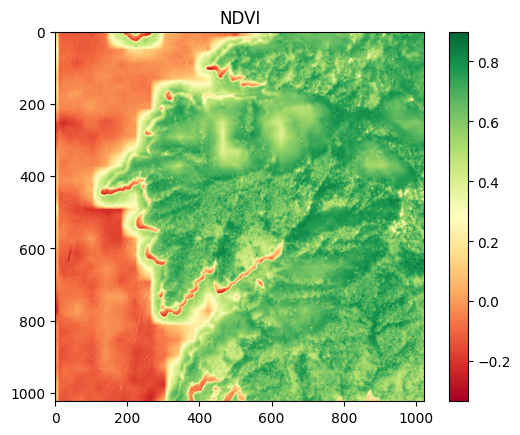

In [35]:
img.show_ndvi()

array([[  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       ...,
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255]],
      shape=(1024, 1024), dtype=uint8)

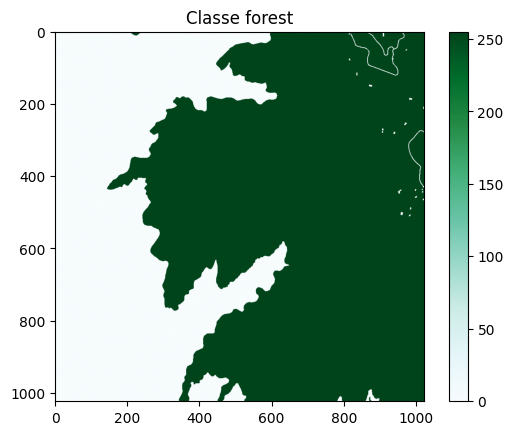

In [37]:
path_classes = path_dataset+path_label


classes = ClassesReader(path_classes)

classes.show_class(3)

array([[  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       ...,
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255]],
      shape=(1024, 1024), dtype=uint8)

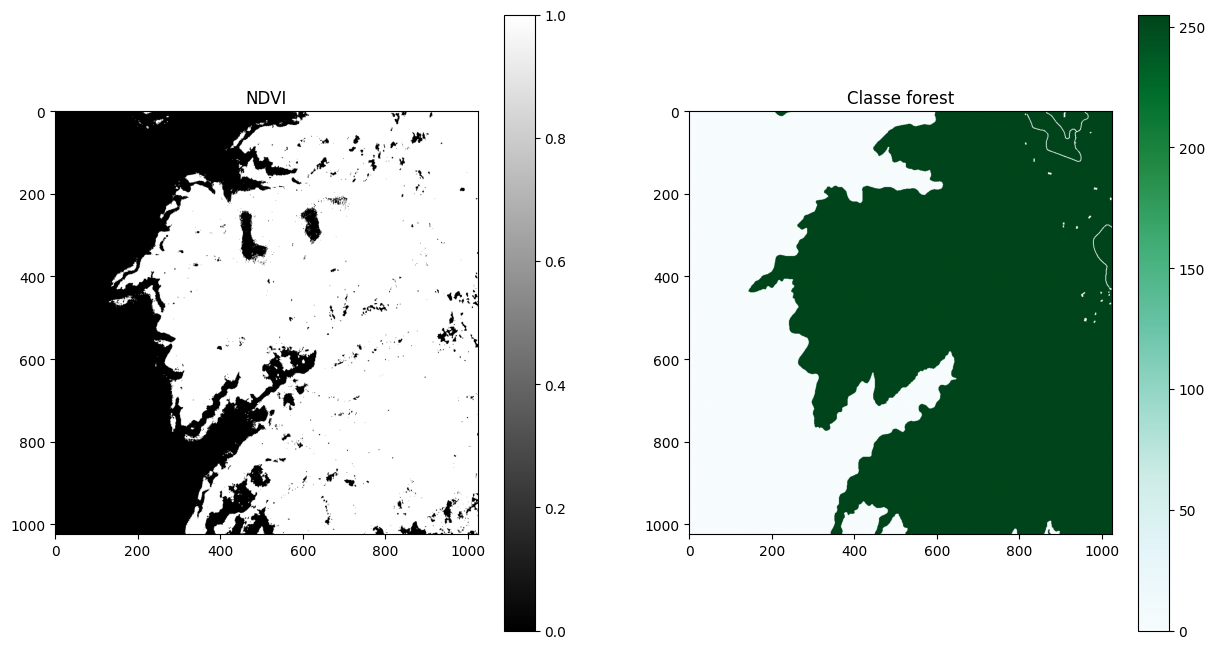

In [39]:
# TODO : change cmap pour show_class / Une cmap personnalisée pour chaque classe comme sur le papier DynamicEarthNet ? 

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
img.show_ndvi(threshold=0.5)
plt.subplot(1, 2, 2)
classes.show_class(3)

Avec un threshold sur le NDVI à 0.85, on retrouve presque le mask de Vegetations obtenu dans le jeu de test.

In [22]:

# TODO : Ajouter des méthodes pour les images raster
# TODO : Ajouter des méthodes pour les images vectorielles



### Compréhension de PF-QA

petite étude du dossier PF-QA

In [11]:
path_img_qa = path_dataset + "planet.10N/planet/10N/23E-188N/1311_3077_13/PF-QA/2018-01-01.tif"

In [12]:
img = SatImageReader(path_img_qa)

In [13]:
img.get_n_bands()

9

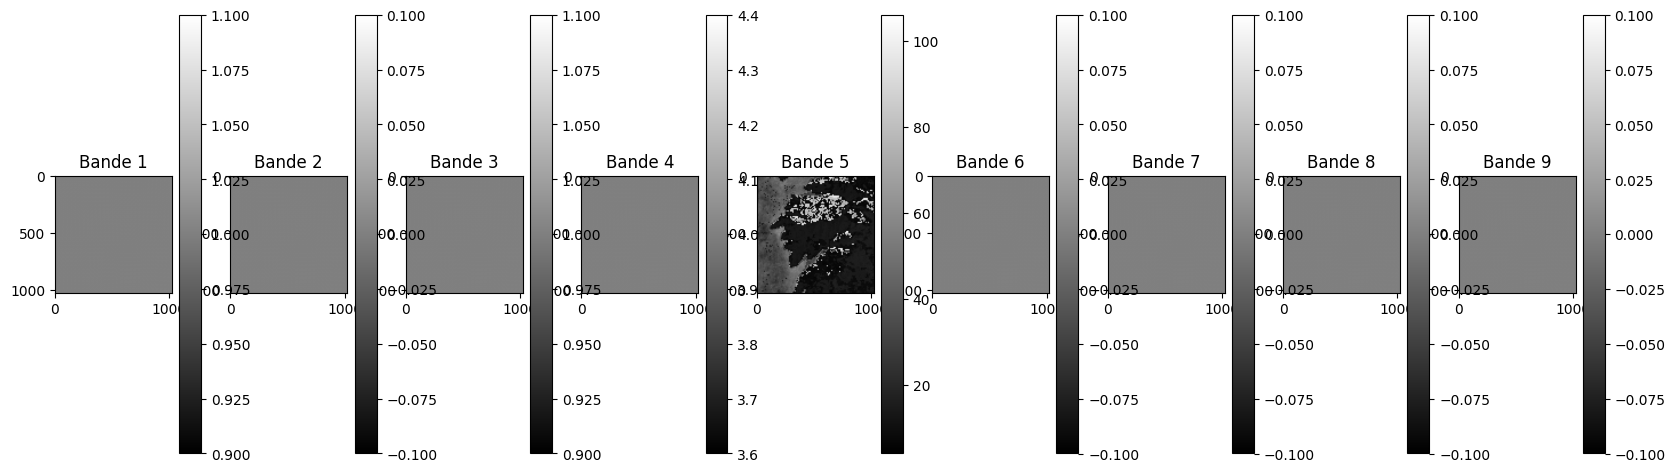

In [15]:
plt.subplots(1, 9, figsize=(20, 10))
for i in range(1, 10):
    plt.subplot(1, 9, i)
    img.show_band(i)
    plt.title(f'Bande {i}')

In [16]:
img.show_metadata()

{'driver': 'GTiff', 'dtype': 'int16', 'nodata': -1000.0, 'width': 1024, 'height': 1024, 'count': 9, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(3.0, 0.0, 551971.4999999972,
       0.0, -3.0, 4517971.500000001)}


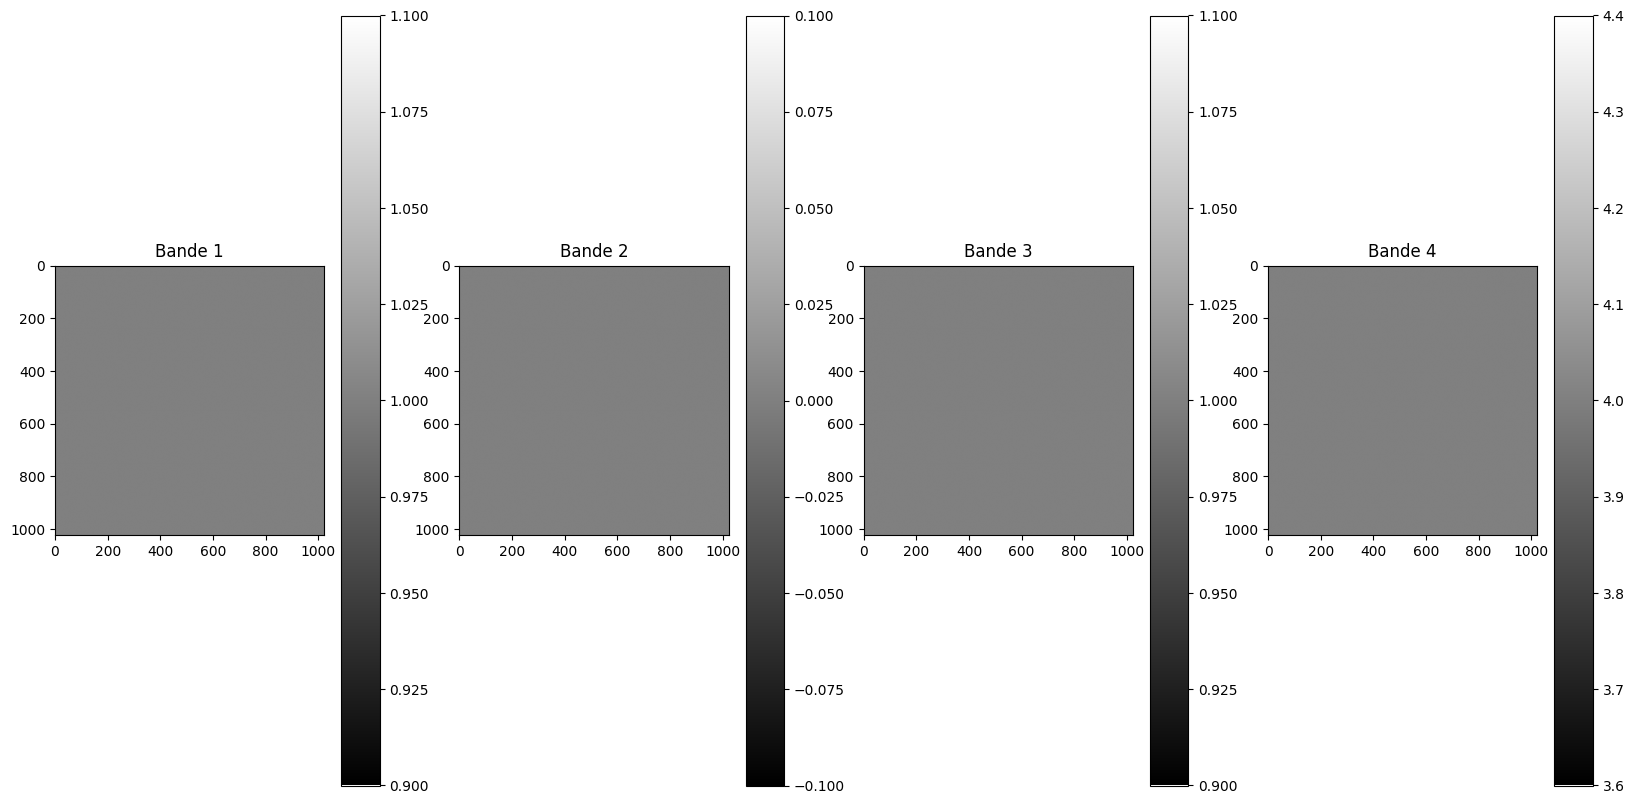

In [17]:
plt.subplots(1, 4, figsize=(20, 10))
for i in range(1, 5):
    plt.subplot(1, 4, i)
    img.show_band(i)
    plt.title(f'Bande {i}')

" The purpose of this is to denote which
parts of the data are raw observations and which parts are
gap-filled with temporally close observations. For every
pixel, the QA product gives the distance and direction to
the day of the observation. For example, a pixel value of -1
implies that the pixel has been filled from the previous day. "

--> Pourquoi nous ne sommes pas en présence d'un masque avec des pixels à 0, -1, +1 etc.. ? 

# Etude des classes avant/après

In [38]:
BASE_PATH = path_dataset + "labels/labels/1311_3077_13_10N/Labels/Raster/10N-122W-40N-L3H-SR/"
BEGIN = "10N-122W-40N-L3H-SR-2018_01_01.tif"
END = "10N-122W-40N-L3H-SR-2019_12_01.tif"

In [39]:
classes_begin = ClassesReader(BASE_PATH + BEGIN)
classes_end = ClassesReader(BASE_PATH + END)

Exception ignored in: <function ClassesReader.__del__ at 0x7f85a3787760>
Traceback (most recent call last):
  File "/home/ids/henry-24/Computer_Vision_Projet/src/classes_reader.py", line 32, in __del__
    if self.image and not self.image.closed:
AttributeError: 'ClassesReader' object has no attribute 'image'


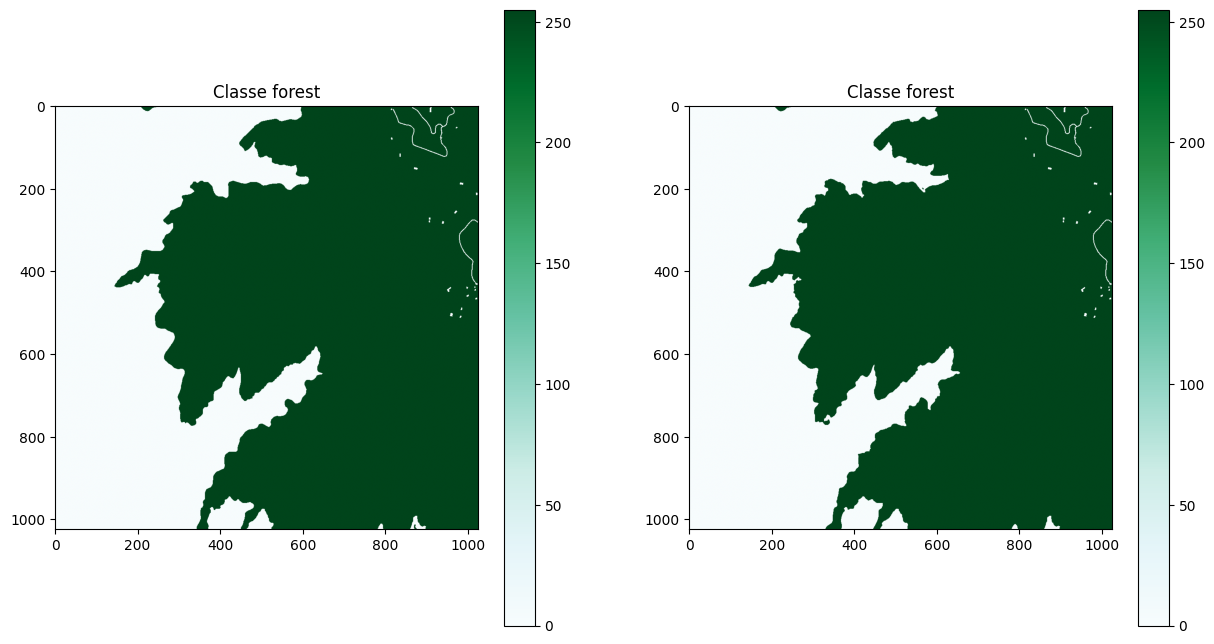

In [40]:
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
data_begin = classes_begin.show_class(3)
plt.subplot(1, 2, 2)
data_end = classes_end.show_class(3)

In [41]:
deforestation = data_begin- data_end

Text(0.5, 1.0, 'Classe Forest_and_Other_Vegetation/ 01/01/18 - 12/12/19')

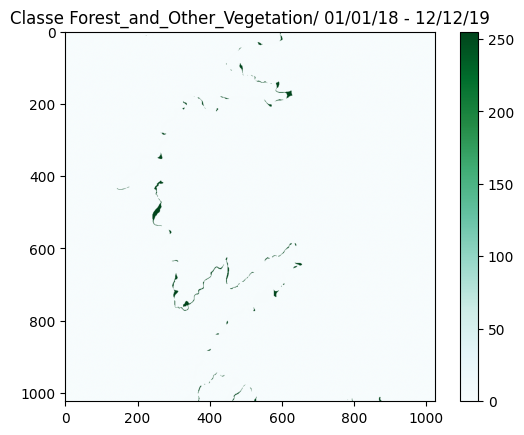

In [42]:
plt.imshow(deforestation, cmap="BuGn")
plt.colorbar()
plt.title(f"Classe Forest_and_Other_Vegetation/ 01/01/18 - 12/12/19")

In [53]:
IMAGE_BEGIN = path_dataset+"planet.10N/planet/10N/23E-188N/1311_3077_13/PF-SR/2018-01-01.tif"
image_begin = SatImageReader(IMAGE_BEGIN)

IMAGE_END = path_dataset+"planet.10N/planet/10N/23E-188N/1311_3077_13/PF-SR/2019-12-31.tif"
image_end = SatImageReader(IMAGE_END)


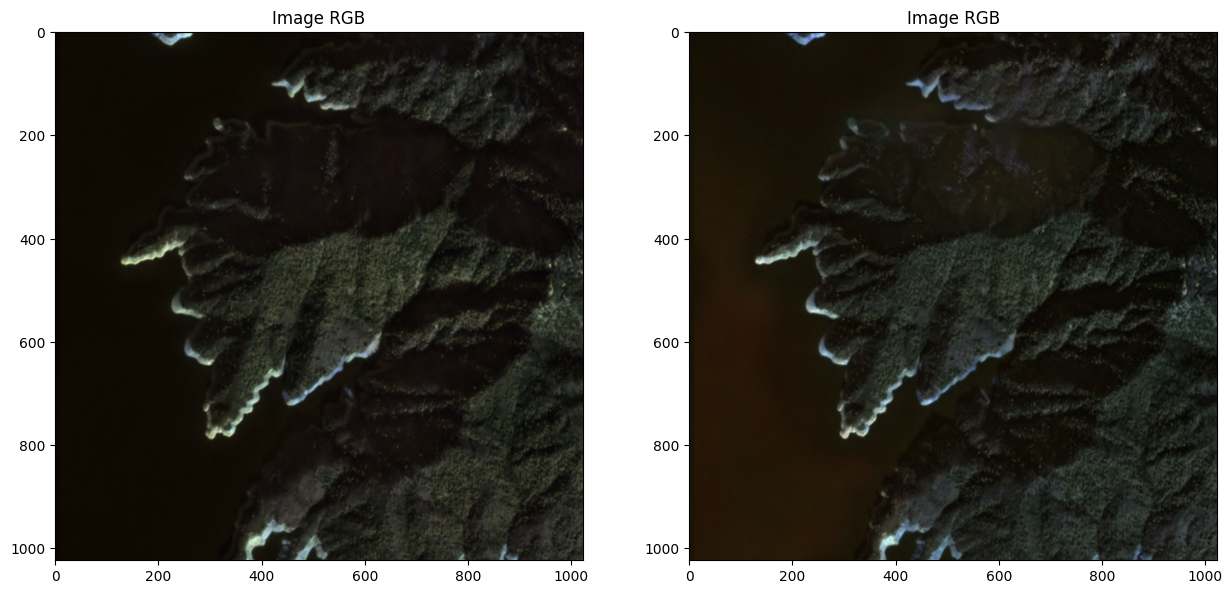

In [54]:
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
image_begin.show_rgb()
plt.subplot(1, 2, 2)
image_end.show_rgb()

Exception ignored in: <function ClassesReader.__del__ at 0x7f85a3787760>
Traceback (most recent call last):
  File "/home/ids/henry-24/Computer_Vision_Projet/src/classes_reader.py", line 32, in __del__
    if self.image and not self.image.closed:
AttributeError: 'ClassesReader' object has no attribute 'image'


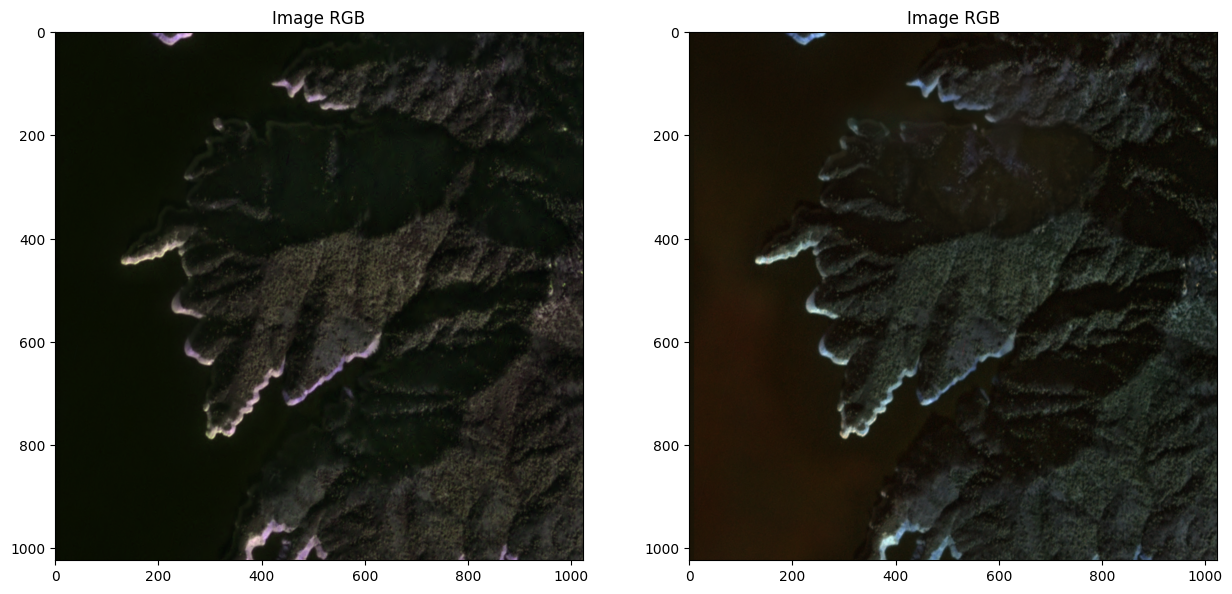

In [55]:
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
image_begin.show_rgb((2,1,3))
plt.subplot(1, 2, 2)
image_end.show_rgb((1,2,3))

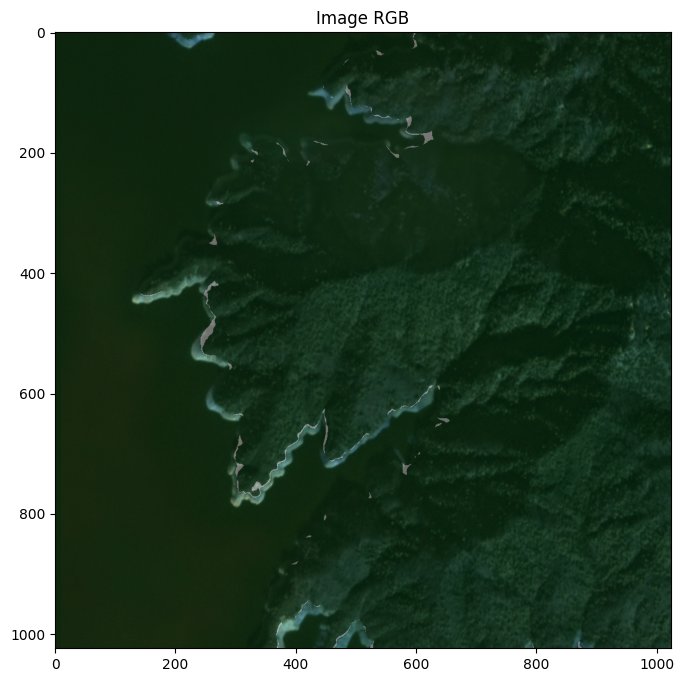

In [56]:
# supperposition de image_end et du masque de deforestation
plt.figure(figsize=(15, 8))
image_end.show_rgb()
plt.imshow(255-deforestation, cmap="BuGn", alpha=0.4)
plt.show()

In [57]:


ClassesReader(BASE_PATH+END).detect_classes()

[1, 3, 5, 6]

array([[  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       ...,
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255]],
      shape=(1024, 1024), dtype=uint8)

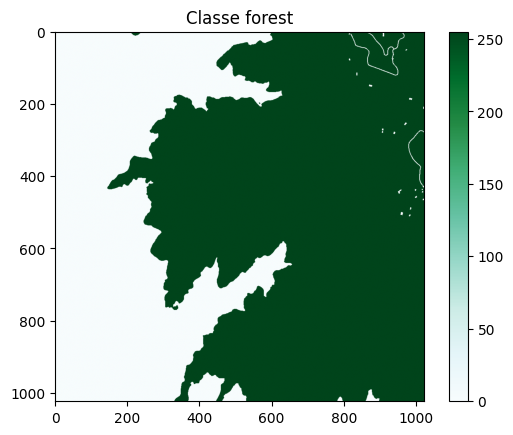

In [58]:
classes_end.show_class(3)

[array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(1024, 1024), dtype=uint8),
 array([[  0,   0,   0, ..., 255, 255, 255],
        [  0,   0,   0, ..., 255, 255, 255],
        [  0,   0,   0, ..., 255, 255, 255],
        ...,
        [  0,   0,   0, ..., 255, 255, 255],
        [  0,   0,   0, ..., 255, 255, 255],
        [  0,   0,   0, ..., 255, 255, 255]],
       shape=(1024, 1024), dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(1024, 1024), dtype=uint8),
 array([[255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        ...,
        [255, 255, 255, ...,   0,  

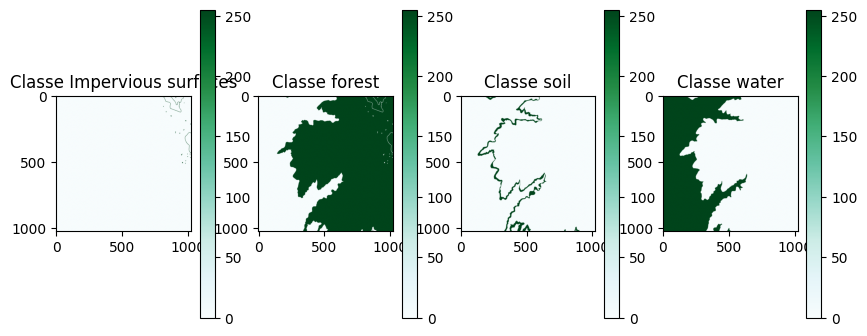

In [59]:
plt.figure(figsize=(10, 4))
classes_begin.show_class_list()

[array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(1024, 1024), dtype=uint8),
 array([[  0,   0,   0, ..., 255, 255, 255],
        [  0,   0,   0, ..., 255, 255, 255],
        [  0,   0,   0, ..., 255, 255, 255],
        ...,
        [  0,   0,   0, ..., 255, 255, 255],
        [  0,   0,   0, ..., 255, 255, 255],
        [  0,   0,   0, ..., 255, 255, 255]],
       shape=(1024, 1024), dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(1024, 1024), dtype=uint8),
 array([[255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        ...,
        [255, 255, 255, ...,   0,  

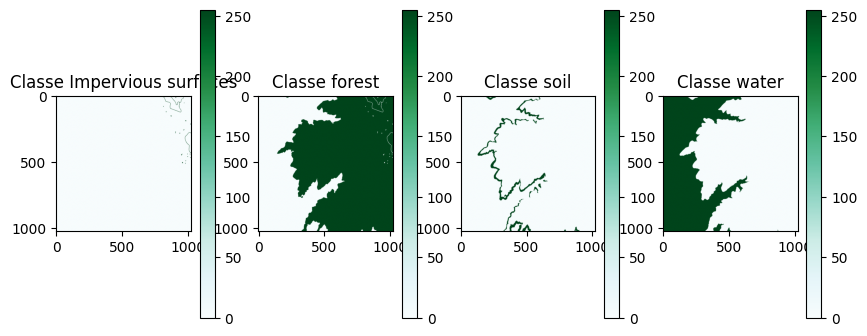

In [60]:
plt.figure(figsize=(10, 4))
classes_end.show_class_list()

# Etude des meta-datas

In [43]:
# TODO : Tester Convnext avec tête U-net 
# TODO : Analyse et compréhension des métadonnées, à quoi correspondent-elles ?
# TODO : Verifier l'alignement des images
# TODO : Pourquoi certians classes ont plusieurs valeurs 